In [1]:
#!pip install "numpy==1.26.4" pandas pmdarima --force-reinstall --no-cache-dir -q

In [2]:

#!pip install "numpy==1.26.4" --force-reinstall --no-cache-dir -q
#!pip install pmdarima keras-tuner statsmodels scikit-learn seaborn matplotlib requests pandas -q

import os
import time
import requests
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Machine Learning & Stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import auto_arima

# Deep Learning & Tuning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

os.environ['PYDEVD_DISABLE_FILE_VALIDATION'] = '1'
warnings.filterwarnings('ignore')
%matplotlib inline













In [3]:

print("Fetching 1 year of historical pollution data via API...")

API_KEY = "4c4f07c1199e3498477b60ee537e5d6f"
# Using Panipat Refinery coordinates as the primary training source
lat, lon = 29.4449, 76.8770

end_date = datetime.now()
start_date = end_date - timedelta(days=365)
start_unix = int(time.mktime(start_date.timetuple()))
end_unix = int(time.mktime(end_date.timetuple()))

url = f"http://api.openweathermap.org/data/2.5/air_pollution/history?lat={lat}&lon={lon}&start={start_unix}&end={end_unix}&appid={API_KEY}"
response = requests.get(url)
data = response.json()

records = []
if 'list' in data:
    for item in data['list']:
        record = item['components']
        record['date'] = datetime.fromtimestamp(item['dt'])
        records.append(record)
else:
    raise ValueError("Error fetching data. Check API key or rate limits.")

df = pd.DataFrame(records)
df.set_index('date', inplace=True)

# Interpolate missing values and backfill edges
pollutants = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']
df = df[pollutants].interpolate(method='time').bfill()
 
# Proxy AQI Target for Modeling
df['Target_AQI'] = df.max(axis=1) * 1.5
print(f"Successfully loaded and cleaned {len(df)} hours of historical data.")

Fetching 1 year of historical pollution data via API...
Successfully loaded and cleaned 8544 hours of historical data.



Performing Correlation Analysis...


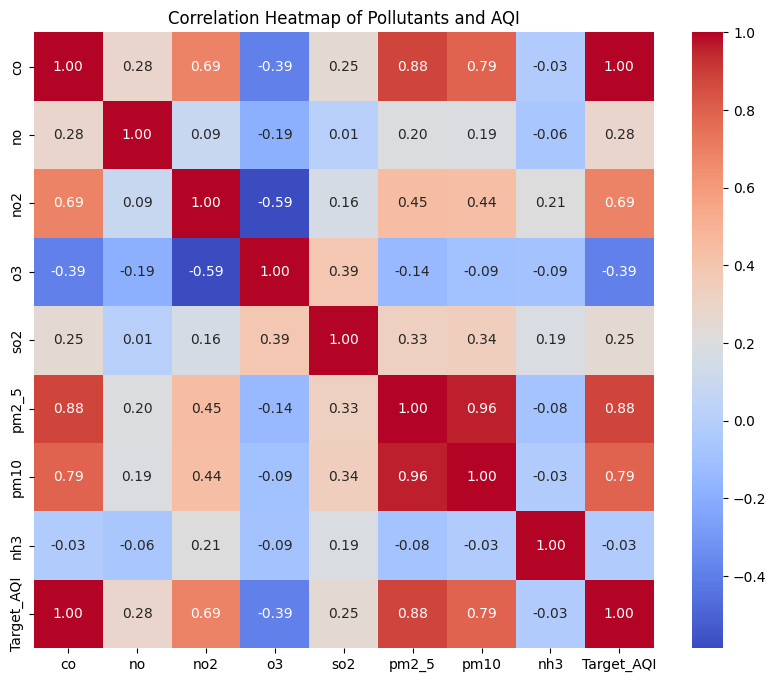

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

print("\nPerforming Correlation Analysis...")

plt.figure(figsize=(10, 8))
corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Pollutants and AQI")
plt.show()


Performing Seasonal Decomposition on Target AQI...


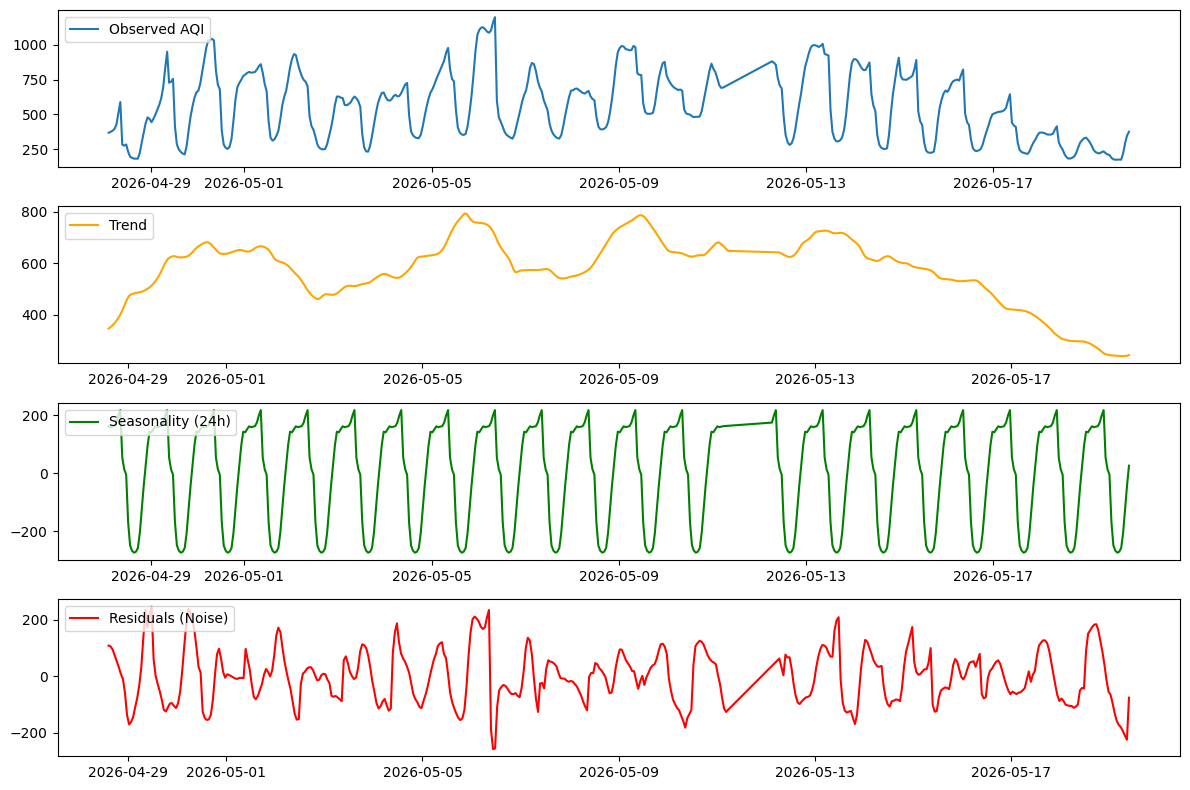

In [5]:

print("\nPerforming Seasonal Decomposition on Target AQI...")
decomposition = seasonal_decompose(df['Target_AQI'][-500:], model='additive', period=24)

plt.figure(figsize=(12, 8))
plt.subplot(411)
plt.plot(decomposition.observed, label='Observed AQI')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='orange')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality (24h)', color='green')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals (Noise)', color='red')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [6]:

print("\nPerforming Feature Selection...")
X_fs = df.drop(columns=['Target_AQI'])
y_fs = df['Target_AQI']

rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_fs, y_fs)

feature_importances = pd.Series(rf.feature_importances_, index=X_fs.columns).sort_values(ascending=False)

# Select features contributing more than 5% importance
selected_features = feature_importances[feature_importances > 0.05].index.tolist()
print(f"Selected Features for Hybrid Model: {selected_features}")

final_data = df[selected_features + ['Target_AQI']]


Performing Feature Selection...
Selected Features for Hybrid Model: ['co']


In [7]:

# Train-Test Split
train_size = int(len(final_data) * 0.8)
train_data = final_data.iloc[:train_size]
test_data = final_data.iloc[train_size:]

# --- STEP A: ARIMA MODEL ---
print("\nTraining ARIMA Model to capture linear trends...")
arima_model = auto_arima(train_data['Target_AQI'], seasonal=False, stepwise=True, trace=False, suppress_warnings=True)
print(f"Optimal ARIMA Order: {arima_model.order}")

train_arima_preds = arima_model.predict_in_sample()
arima_residuals = train_data['Target_AQI'] - train_arima_preds

# --- STEP B: LSTM MODEL ON RESIDUALS ---
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(train_data[selected_features])
X_test_scaled = scaler_X.transform(test_data[selected_features])
y_train_scaled = scaler_y.fit_transform(arima_residuals.values.reshape(-1, 1))

def create_seq(X, y, length=24):
    X_seq, y_seq = [], []
    for i in range(length, len(X)):
        X_seq.append(X[i-length:i])
        if y is not None:
            y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq) if y is not None else None

X_seq_train, y_seq_train = create_seq(X_train_scaled, y_train_scaled, length=24)

# Keras Tuner Architecture
def build_model(hp):
    model = Sequential()
    model.add(LSTM(units=hp.Int('units_1', min_value=32, max_value=128, step=32),
                   return_sequences=True, input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])))
    model.add(Dropout(hp.Float('dropout_1', min_value=0.1, max_value=0.4, step=0.1)))
    model.add(LSTM(units=hp.Int('units_2', min_value=16, max_value=64, step=16)))
    model.add(Dropout(hp.Float('dropout_2', min_value=0.1, max_value=0.4, step=0.1)))
    model.add(Dense(1))

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate), loss='mse')
    return model

print("\nStarting Hyperparameter Tuning for LSTM...")
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=3,
    executions_per_trial=1,
    directory='lstm_tuning',
    project_name='iocl_aqi_hybrid'
)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 80/20 Validation split for tuning
val_split = int(len(X_seq_train) * 0.8)
X_t, y_t = X_seq_train[:val_split], y_seq_train[:val_split]
X_v, y_v = X_seq_train[val_split:], y_seq_train[val_split:]

tuner.search(X_t, y_t, epochs=10, validation_data=(X_v, y_v), callbacks=[early_stop], verbose=0)
best_lstm = tuner.get_best_models(num_models=1)[0]


Training ARIMA Model to capture linear trends...
Optimal ARIMA Order: (5, 1, 3)

Starting Hyperparameter Tuning for LSTM...
Reloading Tuner from lstm_tuning/iocl_aqi_hybrid/tuner0.json


In [ ]:
from tqdm import tqdm
import numpy as np


print("\nEvaluating Hybrid Model on Test Set...")

# Define how many hours we actually want to plot and evaluate (e.g., last 200 hours)
EVAL_HOURS = 200

# 1. Fast-forward the ARIMA model
# We give it the bulk of the test data all at once to update its internal state instantly
catch_up_data = test_data['Target_AQI'].values[:-EVAL_HOURS]
arima_model.update(catch_up_data)

# 2. Rolling 1-Step ARIMA Forecast (Only on the last 200 hours)
print(f"Generating rolling ARIMA predictions for the final {EVAL_HOURS} hours...")
arima_test_preds = []
test_actuals = test_data['Target_AQI'].values[-EVAL_HOURS:]

for i in tqdm(range(len(test_actuals)), desc="ARIMA Progress"):
    raw_pred = arima_model.predict(n_periods=1)
    pred = np.asarray(raw_pred)[0]
    arima_test_preds.append(pred)

    # Update the model step-by-step for these final hours
    arima_model.update(test_actuals[i])

arima_test_preds_aligned = np.array(arima_test_preds)

# 3. LSTM Residual Predictions
# We generate all LSTM predictions normally...
X_seq_test, _ = create_seq(X_test_scaled, None, length=24)
lstm_residual_preds_scaled = best_lstm.predict(X_seq_test, verbose=0)
lstm_residual_preds = scaler_y.inverse_transform(lstm_residual_preds_scaled).flatten()

# ...but we ONLY slice the last 200 to match our ARIMA predictions
lstm_aligned = lstm_residual_preds[-EVAL_HOURS:]
actual_test_aqi = test_actuals

# 4. Final Prediction = Linear (ARIMA) + Non-Linear (LSTM Residuals)
final_hybrid_preds = arima_test_preds_aligned + lstm_aligned

# Metrics
mae = mean_absolute_error(actual_test_aqi, final_hybrid_preds)
rmse = np.sqrt(mean_squared_error(actual_test_aqi, final_hybrid_preds))
r2 = r2_score(actual_test_aqi, final_hybrid_preds)

print("\n" + "="*40)
print("HYBRID MODEL TEST METRICS (LAST 200 HOURS)")
print("="*40)
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

# Plotting the result
plt.figure(figsize=(14, 6))
plt.plot(actual_test_aqi, label='Actual AQI', color='black', alpha=0.7)
plt.plot(arima_test_preds_aligned, label='ARIMA Only', color='blue', linestyle='--')
plt.plot(final_hybrid_preds, label='Hybrid (ARIMA + LSTM)', color='red', linewidth=2)
plt.title(f"Hybrid Model vs Actual AQI Forecast (Last {EVAL_HOURS} hours)")
plt.ylabel("AQI Proxy")
plt.xlabel("Hours")
plt.legend()
plt.show()


Evaluating Hybrid Model on Test Set...
Generating rolling ARIMA predictions for the final 200 hours...


ARIMA Progress:  34%|███▍      | 68/200 [00:52<01:40,  1.31it/s]

In [ ]:

IOCL_REFINERIES = {
    "panipat": ("Panipat Refinery", 29.4449, 76.8770),
    "mathura": ("Mathura Refinery", 27.3826, 77.6698),
    "paradip": ("Paradip Refinery", 20.2706, 86.6340),
    "haldia": ("Haldia Refinery", 22.0401, 88.0863),
    "koyali": ("Gujarat Refinery", 22.3664, 73.1463),
    "barauni": ("Barauni Refinery", 25.4055, 86.0463)
}

def get_live_refinery_pollution(refinery_key):
    if refinery_key not in IOCL_REFINERIES:
        return None
    name, r_lat, r_lon = IOCL_REFINERIES[refinery_key]
    live_url = f"http://api.openweathermap.org/data/2.5/air_pollution?lat={r_lat}&lon={r_lon}&appid={API_KEY}"
    try:
        live_data = requests.get(live_url, timeout=10).json()
        comp = live_data['list'][0]['components']
        print(f"\n[{name}] Live Data Successfully Fetched:")
        for p, v in comp.items():
            print(f" - {p.upper()}: {v}")
        return comp
    except Exception as e:
        print(f"API Error for {name}: {e}")
        return None

# Example Usage
get_live_refinery_pollution("panipat")
get_live_refinery_pollution("mathura")


[Panipat Refinery] Live Data Successfully Fetched:
 - CO: 712.48
 - NO: 2.03
 - NO2: 14.48
 - O3: 70.75
 - SO2: 9.98
 - PM2_5: 67.47
 - PM10: 84.35
 - NH3: 44.38

[Mathura Refinery] Live Data Successfully Fetched:
 - CO: 480.88
 - NO: 0.31
 - NO2: 3.72
 - O3: 106.53
 - SO2: 1.71
 - PM2_5: 59.38
 - PM10: 69.29
 - NH3: 16.7


{'co': 480.88,
 'no': 0.31,
 'no2': 3.72,
 'o3': 106.53,
 'so2': 1.71,
 'pm2_5': 59.38,
 'pm10': 69.29,
 'nh3': 16.7}

In [ ]:
import joblib

print("Exporting Models and Scalers...")

# 1. Save the Deep Learning LSTM Model (Keras format)
best_lstm.save('iocl_lstm_hybrid.keras')

# 2. Save the Statistical ARIMA Model (Pickle format)
joblib.dump(arima_model, 'iocl_arima_hybrid.pkl')

# 3. Save the Scalers (Absolutely essential for future live predictions!)
joblib.dump(scaler_X, 'iocl_scaler_X.pkl')
joblib.dump(scaler_y, 'iocl_scaler_y.pkl')

print("✅ All files successfully saved to your Colab environment!")

Exporting Models and Scalers...
✅ All files successfully saved to your Colab environment!
